Loading dataset from D:/path_finder/fake_student_performance_dataset.csv ...
Loaded dataset with shape: (1200, 40)
Preprocessing data...
Balanced 'AtRisk' class distribution:
AtRisk
1    724
0    476
Name: count, dtype: int64
Using 35 features for modeling.
Feature data types after encoding/scaling:
float64    23
int32      12
Name: count, dtype: int64

Training XGBoost classifier for 'AtRisk' prediction...
Class distribution before split:
AtRisk
1    724
0    476
Name: count, dtype: int64
Class distribution in training set:
AtRisk
1    579
0    381
Name: count, dtype: int64
Class distribution in test set:
AtRisk
1    145
0     95
Name: count, dtype: int64


c:\Users\JYOTI GUPTA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:01:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classifier accuracy: 0.9958
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        95
           1       1.00      0.99      1.00       145

    accuracy                           1.00       240
   macro avg       0.99      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

Confusion Matrix:
 [[ 95   0]
 [  1 144]]

Training XGBoost regressor for 'Internal Marks' prediction...
Regressor MSE: 0.0012
Regressor R^2 score: 0.9988

Generating SHAP explainability plots...
SHAP summary plot (beeswarm)...


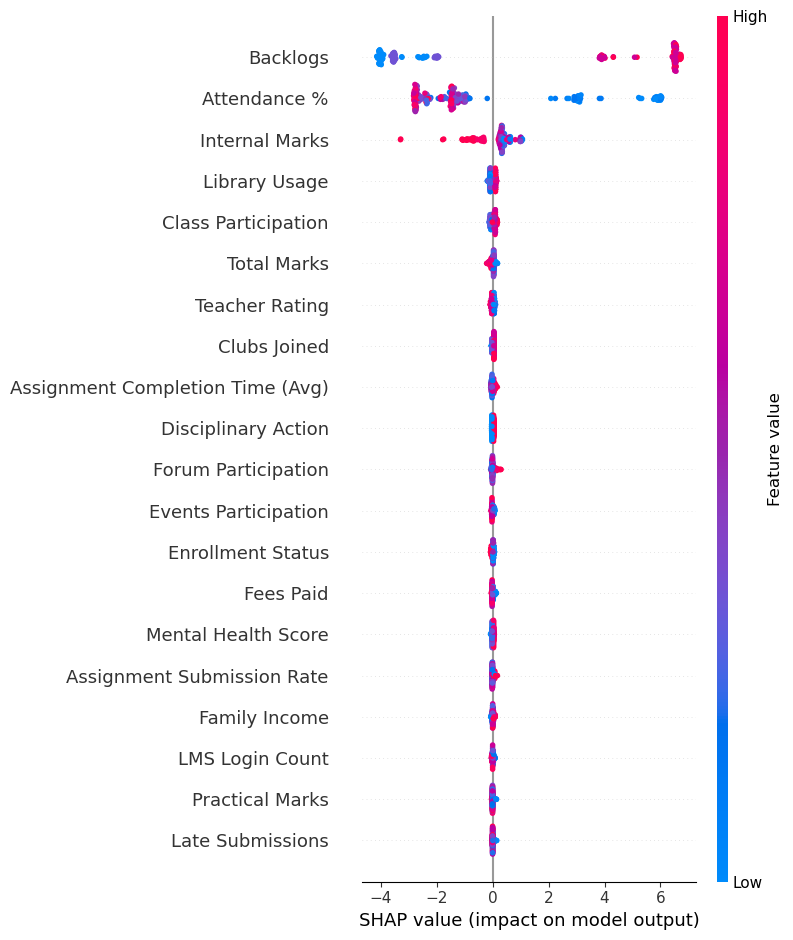

SHAP feature importance plot (bar)...


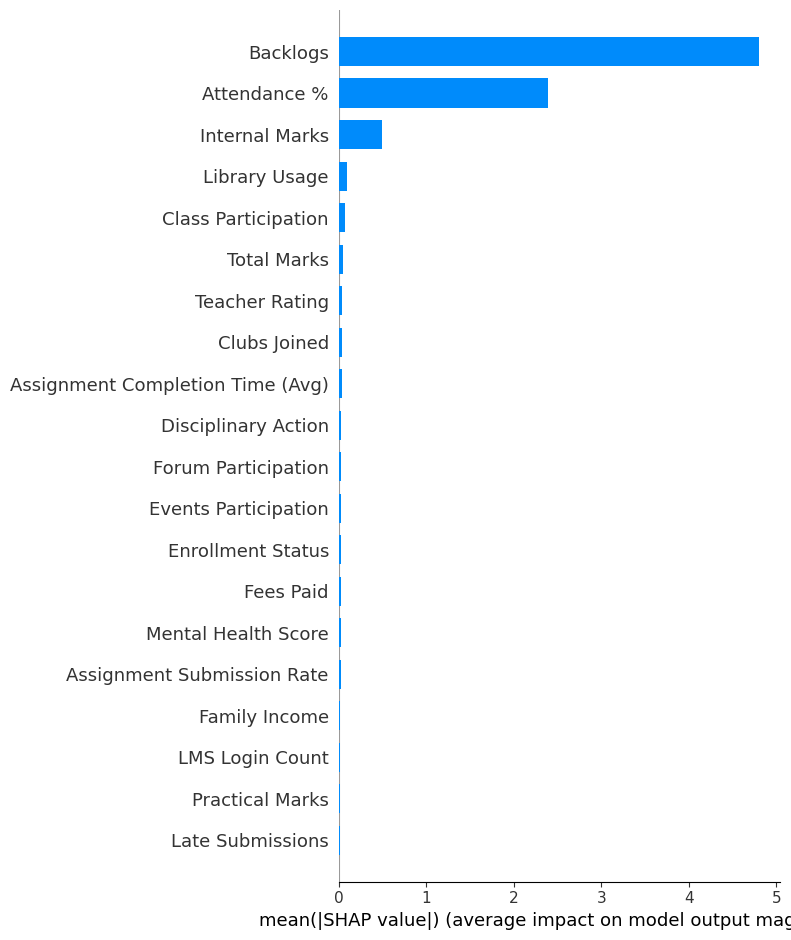

SHAP dependence plot for feature: Backlogs


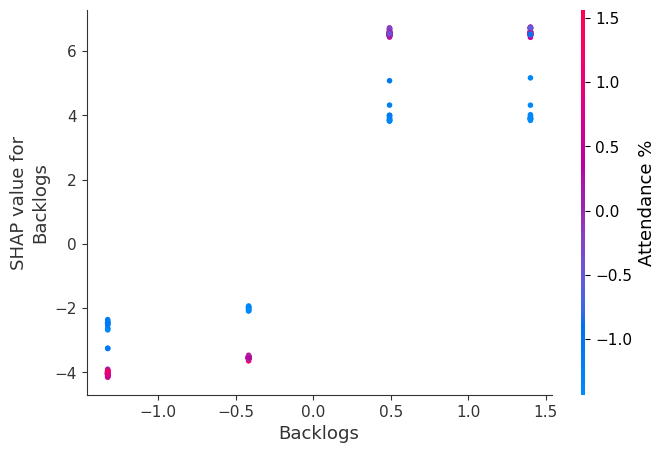


Generating actionable suggestions and saving to outputs\at_risk_suggestions.csv...
Suggestions saved to outputs\at_risk_suggestions.csv
Predictions saved to outputs\at_risk_predictions.csv
Predictions saved to outputs\regression_predictions.csv


In [41]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score
)

# --------- Configuration ----------
DATA_PATH = 'D:/path_finder/fake_student_performance_dataset.csv'  # Change as per your path
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------- Data Loading & Preprocessing ---------
def load_data(filepath):
    print(f"Loading dataset from {filepath} ...")
    df = pd.read_csv(filepath)
    print(f"Loaded dataset with shape: {df.shape}")
    return df

def preprocess_data(df):
    print("Preprocessing data...")

    # Strip whitespace from columns
    df = df.rename(columns=lambda x: x.strip())

    # Convert 'Year' to numeric or categorical encoding
    if 'Year' in df.columns:
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        if df['Year'].isnull().any():
            le_year = LabelEncoder()
            df['Year'] = le_year.fit_transform(df['Year'].astype(str))

    # Convert 'Stress Level' similarly
    if 'Stress Level' in df.columns:
        df['Stress Level'] = pd.to_numeric(df['Stress Level'], errors='coerce')
        if df['Stress Level'].isnull().any():
            le_stress = LabelEncoder()
            df['Stress Level'] = le_stress.fit_transform(df['Stress Level'].astype(str))

    # Create balanced 'AtRisk' label with stricter thresholds
    df['AtRisk'] = (((df['Attendance %'] < 60) & (df['Internal Marks'] < 30)) | (df['Backlogs'] > 1)).astype(int)

    print("Balanced 'AtRisk' class distribution:")
    print(df['AtRisk'].value_counts())

    # Drop rows with missing crucial fields
    critical_columns = ['Attendance %', 'Internal Marks', 'AtRisk']
    df = df.dropna(subset=critical_columns)

    # Encode categorical columns
    categorical_cols = [
        'Gender', 'Caste', 'Course', 'Parental Education', 'Internet Availability at Home',
        'Enrollment Status', 'Clubs Joined', 'Events Participation', 'Volunteer Activities',
        'Counselling Opted', 'Medical History Reported', 'Disciplinary Action', 'Scholarship Received'
    ]
    label_encoders = {}
    for col in categorical_cols:
        if col in df.columns and df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le

    # Define features for modeling (only include columns present)
    feature_cols = [
        'Year', 'Semester', 'Gender', 'Age', 'Caste', 'Family Income', 'Internal Marks',
        'Theory Marks', 'Practical Marks', 'Backlogs', 'Fees Paid', 'Scholarship Received',
        'Teacher Rating', 'Library Usage', 'Medical History Reported', 'Disciplinary Action',
        'Attendance %', 'Assignment Submission Rate', 'Class Participation', 'Late Submissions',
        'LMS Login Count', 'Video Lectures Watched', 'Forum Participation', 'Study Hours/Week',
        'Assignment Completion Time (Avg)', 'Parental Education', 'Internet Availability at Home',
        'Stress Level', 'Mental Health Score', 'Counselling Opted', 'Clubs Joined', 'Events Participation',
        'Volunteer Activities', 'Enrollment Status'
    ]
    feature_cols = [col for col in feature_cols if col in df.columns]

    # Add Total Marks feature if available
    if all(col in df.columns for col in ['Internal Marks', 'Theory Marks', 'Practical Marks']):
        df['Total Marks'] = df['Internal Marks'] + df['Theory Marks'] + df['Practical Marks']
        feature_cols.append('Total Marks')

    # Scale numeric features
    numeric_cols = df[feature_cols].select_dtypes(include=['int64', 'float64']).columns
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    print(f"Using {len(feature_cols)} features for modeling.")
    print("Feature data types after encoding/scaling:")
    print(df[feature_cols].dtypes.value_counts())

    return df, label_encoders, scaler, feature_cols

# --------- Modeling ---------
def train_classifier(df, feature_cols, target_col='AtRisk'):
    print("\nTraining XGBoost classifier for 'AtRisk' prediction...")
    X = df[feature_cols]
    y = df[target_col]

    print("Class distribution before split:")
    print(y.value_counts())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print("Class distribution in training set:")
    print(y_train.value_counts())
    print("Class distribution in test set:")
    print(y_test.value_counts())

    model = xgb.XGBClassifier(
        max_depth=5,
        learning_rate=0.08,
        n_estimators=200,
        subsample=0.85,
        colsample_bytree=0.85,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"Classifier accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return model, X_test, y_test, y_pred

def train_regressor(df, feature_cols, target_col='Internal Marks'):
    print("\nTraining XGBoost regressor for 'Internal Marks' prediction...")
    if target_col not in df.columns:
        print(f"Warning: Target '{target_col}' not found. Skipping regression.")
        return None, None, None, None

    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = xgb.XGBRegressor(
        max_depth=5,
        learning_rate=0.08,
        n_estimators=200,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='reg:squarederror',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Regressor MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"Regressor R^2 score: {r2_score(y_test, y_pred):.4f}")

    return model, X_test, y_test, y_pred

# --------- SHAP Explainability ---------
def shap_explanations(model, X_test):
    print("\nGenerating SHAP explainability plots...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    print("SHAP summary plot (beeswarm)...")
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)

    print("SHAP feature importance plot (bar)...")
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

    top_feature = X_test.columns[abs(shap_values).mean(0).argmax()]
    print(f"SHAP dependence plot for feature: {top_feature}")
    shap.dependence_plot(top_feature, shap_values, X_test, show=True)

    return explainer, shap_values

# --------- Rule-Based Suggestions ---------
def generate_and_export_suggestions(X_test, y_true, y_pred, filename):
    print(f"\nGenerating actionable suggestions and saving to {filename}...")

    df_sugg = X_test.copy()
    df_sugg['Actual AtRisk'] = y_true.values
    df_sugg['Predicted AtRisk'] = y_pred

    suggestions = []
    for _, row in df_sugg.iterrows():
        if row['Predicted AtRisk'] == 1:
            sugg = []
            if 'Attendance %' in row and row['Attendance %'] < 0:
                sugg.append("Improve attendance")
            if 'Backlogs' in row and row['Backlogs'] > 0:
                sugg.append("Clear backlogs")
            if 'Assignment Submission Rate' in row and row['Assignment Submission Rate'] < 0:
                sugg.append("Increase assignment submissions")
            if not sugg:
                sugg.append("Regular monitoring recommended")
        else:
            sugg = ["No immediate action required"]
        suggestions.append("; ".join(sugg))

    df_sugg['Suggestions'] = suggestions
    df_sugg.to_csv(filename, index=False)
    print(f"Suggestions saved to {filename}")
    return df_sugg

# --------- Save Predictions ---------
def save_predictions(X_test, y_true, y_pred, filename):
    df_out = X_test.copy()
    df_out['Actual'] = y_true.values
    df_out['Predicted'] = y_pred
    df_out.to_csv(filename, index=False)
    print(f"Predictions saved to {filename}")

# --------- Main Execution ---------
def main():
    df = load_data(DATA_PATH)

    df_processed, label_encoders, scaler, feature_cols = preprocess_data(df)

    clf_model, X_test_clf, y_test_clf, y_pred_clf = train_classifier(df_processed, feature_cols)

    reg_model, X_test_reg, y_test_reg, y_pred_reg = train_regressor(df_processed, feature_cols)

    shap_explanations(clf_model, X_test_clf)

    suggestion_csv = os.path.join(OUTPUT_DIR, 'at_risk_suggestions.csv')
    generate_and_export_suggestions(X_test_clf, y_test_clf, y_pred_clf, suggestion_csv)

    pred_csv = os.path.join(OUTPUT_DIR, 'at_risk_predictions.csv')
    save_predictions(X_test_clf, y_test_clf, y_pred_clf, pred_csv)

    if reg_model is not None:
        reg_pred_csv = os.path.join(OUTPUT_DIR, 'regression_predictions.csv')
        save_predictions(X_test_reg, y_test_reg, y_pred_reg, reg_pred_csv)

if __name__ == "__main__":
    main()
